In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from scipy.spatial import KDTree
from scipy.spatial import ConvexHull
from scipy.interpolate import splprep, splev

In [87]:
rng = np.random.default_rng(2)
# x_train = rng.normal(0.4, 0.2, 13)
# y_train = rng.normal(0.5, 0.15, 13)
x_train = rng.normal(0.4, 0.2, 13)
y_train = rng.normal(0.5, 0.15, 13)

rng2 = np.random.default_rng(1)
additional_x_train = rng2.normal(0.4, 0.1, 25)
additional_y_train = rng2.normal(0.3, 0.17, 25)

In [88]:
train = np.column_stack((x_train, y_train))
train  = np.delete(train, (3), axis=0)

additional_train = np.column_stack((additional_x_train, additional_y_train))[:-2]

In [96]:
# x_test = [0.6, 0.5, 0.2]
# y_test = [0.1, 0.4, 0.8]

x_test = [0.6, 0.4, 0.2]
y_test = [0.1, 0.2, 0.8]

# x_test = [0.6, 0.5, 0.4]
# y_test = [0.2, 0.4, 0.7]

test = np.column_stack((x_test, y_test))
test

array([[0.6, 0.1],
       [0.4, 0.2],
       [0.2, 0.8]])

In [97]:
train.shape, additional_train.shape

((12, 2), (23, 2))

In [98]:
tree = KDTree(train)
distances, indices = tree.query(test, k=3)

nn_train = train[indices]
nn_train.shape

(3, 3, 2)

In [99]:
tree = KDTree(train_together := np.concat((train, additional_train)))
distances, indices = tree.query(test, k=3)

nn_train2 = train_together[indices]
nn_train2.shape

(3, 3, 2)

In [100]:
def get_smooth(train, x_inflation, y_inflation, xskew: float = 0, yskew: float = 0):
    # Compute convex hull
    hull = ConvexHull(train)
    hull_points = train[hull.vertices]

    # Optional: close the loop
    hull_points = np.vstack([hull_points, hull_points[0]])

    # Spline interpolation (smooth the polygon)
    tck, u = splprep([hull_points[:,0], hull_points[:,1]], s=0.01, per=True)  # s controls smoothness
    u_new = np.linspace(0, 1, 300)
    x_smooth, y_smooth = splev(u_new, tck)


    # Optional: “inflate” by scaling
    center = train.mean(axis=0)
    x_smooth = center[0] + (x_smooth - center[0]) * x_inflation + xskew
    y_smooth = center[1] + (y_smooth - center[1]) * y_inflation + yskew

    return x_smooth, y_smooth

In [101]:
x_smooth, y_smooth = get_smooth(train, 1.2, 2.3, 0, yskew=-0.01)
x_smooth2, y_smooth2 = get_smooth(train_together, 1, 1.1, -0.04)

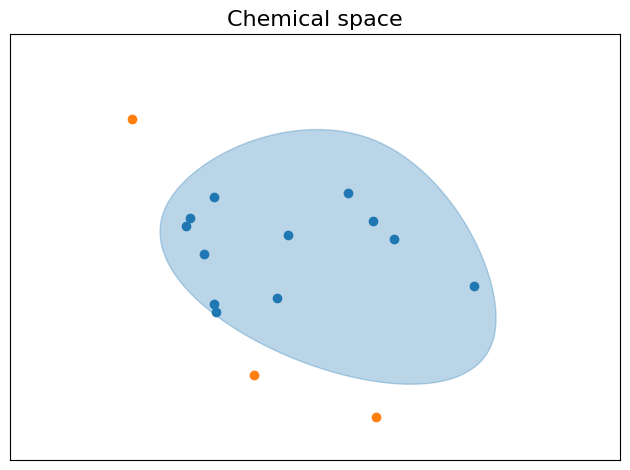

In [102]:
plt.scatter(train[:, 0], train[:, 1], marker='o')
plt.scatter(test[:, 0], test[:, 1], marker='o')

# for point, neighbors in zip(test, nn_train, strict=True):
#     for neighbor in neighbors:
#         plt.annotate(text="", xy=point, xytext=neighbor, arrowprops=dict(arrowstyle="<->"))

plt.fill(x_smooth, y_smooth, color='tab:blue', alpha=0.3)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xticks([])
plt.yticks([])

# plt.title("Small Dataset", fontsize=16)
plt.title("Chemical space", fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
res = 600

xmin = min(x_smooth.min(), x_smooth2.min())
xmax = max(x_smooth.max(), x_smooth2.max())
ymin = min(y_smooth.min(), y_smooth2.min())
ymax = max(y_smooth.max(), y_smooth2.max())

xg = np.linspace(xmin, xmax, res)
yg = np.linspace(ymin, ymax, res)
X, Y = np.meshgrid(xg, yg)

grid_points = np.column_stack([X.ravel(), Y.ravel()])

In [24]:
path1 = Path(np.column_stack([x_smooth, y_smooth]))
path2 = Path(np.column_stack([x_smooth2, y_smooth2]))

mask1 = path1.contains_points(grid_points, radius=-1e-3)
mask2 = path2.contains_points(grid_points, radius=0)

mask_diff = mask2 & (~mask1)
mask_diff = mask_diff.reshape(res, res)

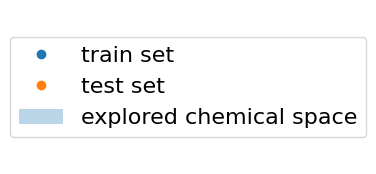

In [107]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

train_legend = Line2D([], [], marker='o', linestyle='None',
                      color='C0', label='train set')

test_legend = Line2D([], [], marker='o', linestyle='None',
                     color='C1', label='test set')

area_legend = Patch(facecolor='tab:blue', alpha=0.3,
                    label='explored chemical space')

# stripe_legend = Patch(facecolor='none',
#                       edgecolor=(0.121, 0.466, 0.705, 0.5),
#                       hatch='///',
#                       label='expanded exploration')

# Create separate legend figure WITH axis
fig_leg, ax_leg = plt.subplots(figsize=(3, 2))
ax_leg.axis('off')  # hide axis

ax_leg.legend(
    # handles=[train_legend, test_legend, area_legend, stripe_legend],
    handles=[train_legend, test_legend, area_legend],
    loc='center',
    frameon=True,
    fontsize=16
)

plt.show()

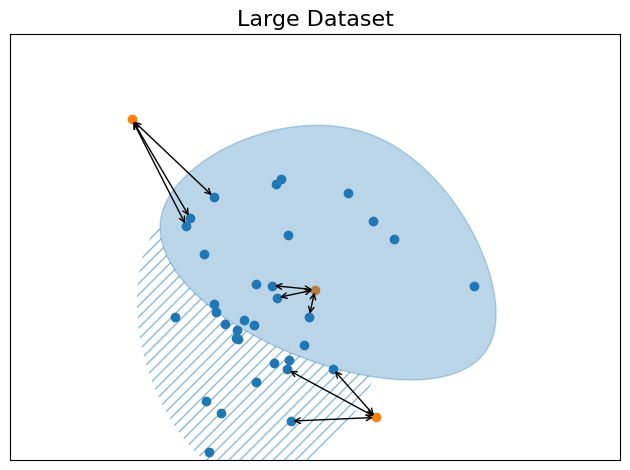

In [26]:
train_scatter = plt.scatter(train[:, 0], train[:, 1], marker='o', label="train set")
plt.scatter(additional_train[:, 0], additional_train[:, 1], color="tab:blue")
test_scatter = plt.scatter(test[:, 0], test[:, 1], marker='o', label="test set")

for point, neighbors in zip(test, nn_train2, strict=True):
    for neighbor in neighbors:
        plt.annotate(text="", xy=point, xytext=neighbor, arrowprops=dict(arrowstyle="<->"))

plt.fill(x_smooth, y_smooth, color='tab:blue', alpha=0.3)

cs = plt.contourf(X, Y, mask_diff, levels=[0.5, 1], colors='none', hatches=['///'])

cs.set_edgecolor((0.121, 0.466, 0.705, 0.5))
cs.set_linewidth(0)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xticks([])
plt.yticks([])

plt.title("Large Dataset", fontsize=16)

plt.tight_layout()
plt.show()

In [34]:
rng3 = np.random.default_rng(5)
x_train_2 = rng3.normal(0.4, 0.05, 13)
y_train_2 = rng3.normal(0.5, 0.1, 13)
train_2 = np.column_stack((x_train_2, y_train_2))

In [38]:
x_test_2 = [0.65, 0.8, 0.7]
y_test_2 = [0.4, 0.5, 0.6]
test_2 = np.column_stack((x_test_2, y_test_2))

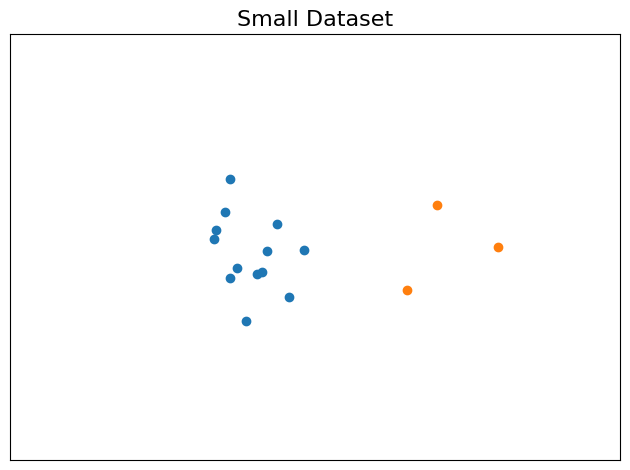

In [39]:
plt.scatter(train_2[:, 0], train_2[:, 1], marker='o')
plt.scatter(test_2[:, 0], test_2[:, 1], marker='o')

# for point, neighbors in zip(test, nn_train, strict=True):
#     for neighbor in neighbors:
#         plt.annotate(text="", xy=point, xytext=neighbor, arrowprops=dict(arrowstyle="<->"))

# plt.fill(x_smooth, y_smooth, color='tab:blue', alpha=0.3)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xticks([])
plt.yticks([])

plt.title("Small Dataset", fontsize=16)
plt.tight_layout()
plt.show()